# Practical 1

## NumPy

In [1]:
import numpy as np

In [9]:
ar1 = np.zeros(10,dtype=np.int32)
ar1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
ar2  = np.ones(10,dtype=np.int32)
ar2

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [18]:
ar3 = np.round(np.random.rand(10)*10,0)
ar3 = ar3.astype(int)
ar3

array([5, 5, 7, 7, 2, 1, 3, 4, 2, 9])

In [22]:
ar4 = np.genfromtxt('./pr1.txt',delimiter=',',dtype=int)
ar4

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [23]:
ar4[:-1]

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [24]:
ar4[5:8]

array([6, 7, 8])

In [25]:
ar4[9] = 12
ar4

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 12])

In [29]:
ar5 = np.reshape(ar4,(5,2))
ar5

array([[ 1,  2],
       [ 3,  4],
       [ 5,  6],
       [ 7,  8],
       [ 9, 12]])

In [30]:
np.transpose(ar5)

array([[ 1,  3,  5,  7,  9],
       [ 2,  4,  6,  8, 12]])

In [32]:
print(ar4)
for i in range (0,len(ar4)):
    ar4[i] = ar4[i] * 2
print(ar4)

[ 1  2  3  4  5  6  7  8  9 12]
[ 2  4  6  8 10 12 14 16 18 24]


In [53]:
from time import time
mat1 = np.round(np.random.rand(1000,1000)*10,0)
mat1 = mat1.astype(int)

mat2 = np.round(np.random.rand(1000,1000)*10,0)
mat2 = mat2.astype(int)

start_np = time()
mat3 = np.matmul(mat1,mat2)
end_np = time()

print(end_np-start_np, 'Seconds')

1.9886441230773926 Seconds


In [54]:
def list_mult(m1,m2):
    c = [ [0 for _ in range(len(m2[0]))] for _ in range(len(m1))]
    for i in range(len(m1)):
        for j in range(len(m2[0])):
            for k in range(len(m2)):
                c[i][j] += m1[i][k]*m2[k][j];
    return c

start = time()
mat5 = list_mult(mat1.copy(),mat2.copy())
end = time()

print(end-start, 'Seconds')

7157.791621685028 Seconds


## Pandas

In [1]:
import pandas as pd 

d = {'Animal':['Tiger','Elephant','Sparrow'],'type':['mammal','mammal','bird']}

df1 = pd.DataFrame(d)
df1

,Animal,type
0,Tiger,mammal
1,Elephant,mammal
2,Sparrow,bird


In [21]:
df = pd.read_csv('./iris.data.csv',sep=',',header=None)

In [22]:
df.columns = ['sepal_length','sepal_width','petal_length','petal_width','species']

In [23]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [24]:
#from 15th row to 20th row
df[15:21]

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,Iris-setosa
16,5.4,3.9,1.3,0.4,Iris-setosa
17,5.1,3.5,1.4,0.3,Iris-setosa
18,5.7,3.8,1.7,0.3,Iris-setosa
19,5.1,3.8,1.5,0.3,Iris-setosa
20,5.4,3.4,1.7,0.2,Iris-setosa


In [25]:
#from 15th row to 20th row odd rows
df[15:21:2]

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,Iris-setosa
17,5.1,3.5,1.4,0.3,Iris-setosa
19,5.1,3.8,1.5,0.3,Iris-setosa


In [34]:
for i in df['species'].unique():
    print('Total rows of', i,':',len(df[df['species']==i]))

Total rows of Iris-setosa : 50
Total rows of Iris-versicolor : 50
Total rows of Iris-virginica : 50


In [35]:
df.to_csv('iris_two.csv')

In [40]:
df1 = pd.DataFrame({'seconds':[120,240,300]})
df1['minutes'] = df1['seconds']/60

df1

,seconds,minutes
0,120,2.0
1,240,4.0
2,300,5.0


In [42]:
df1[df1['seconds']>200]

,seconds,minutes
1,240,4.0
2,300,5.0


In [48]:
df2 = df1['minutes'].mask(df1['minutes']>1)
df2

0   NaN
1   NaN
2   NaN
Name: minutes, dtype: float64

## Matplotlib

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

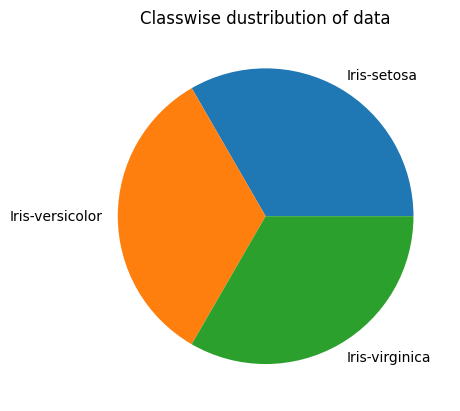

In [64]:
class_len = df['species'].value_counts()
labels = df['species'].unique()
plt.pie(class_len, labels=labels)
plt.title('Classwise dustribution of data')
plt.show()

In [65]:
df2 = pd.read_csv('./Electric_Production.csv')
df2.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


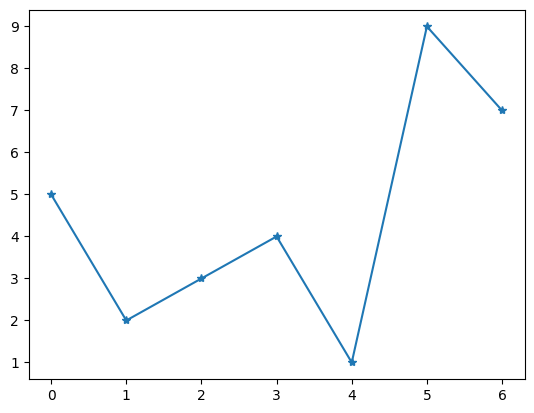

In [75]:
plt.plot([5,2,3,4,1,9,7],marker='*')
plt.show()

In [77]:
corr= df[['sepal_length','sepal_width','petal_length','petal_width']].corr()

<AxesSubplot: >

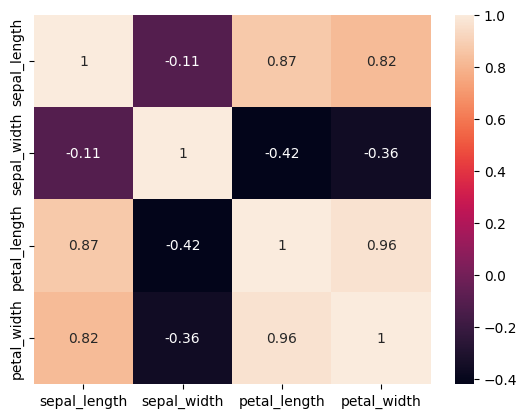

In [79]:
sns.heatmap(corr,annot=True)

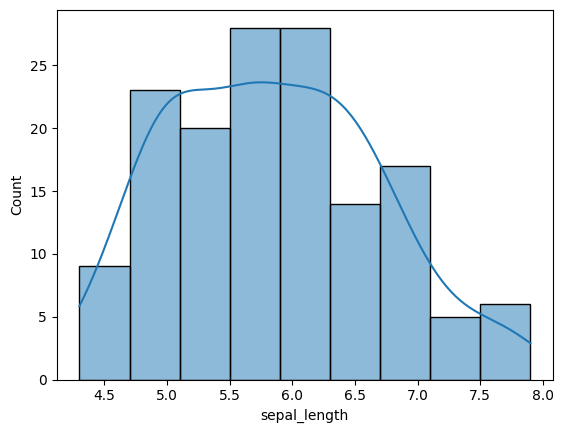

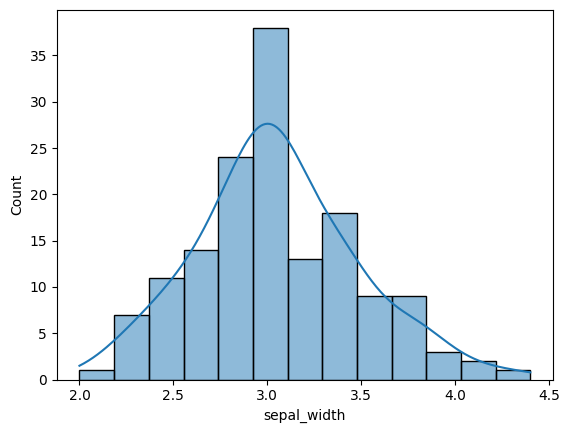

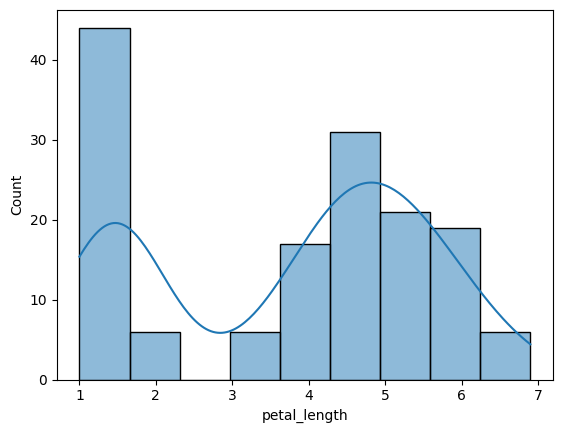

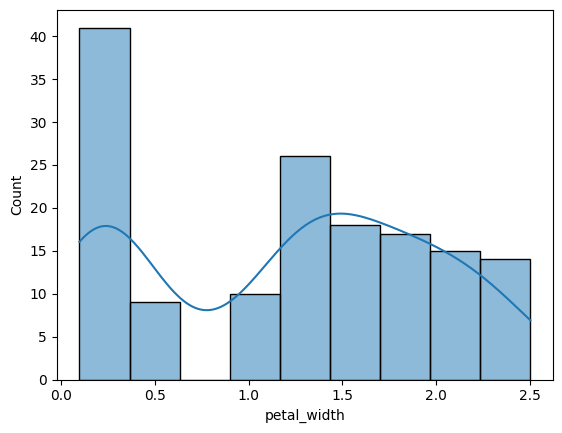

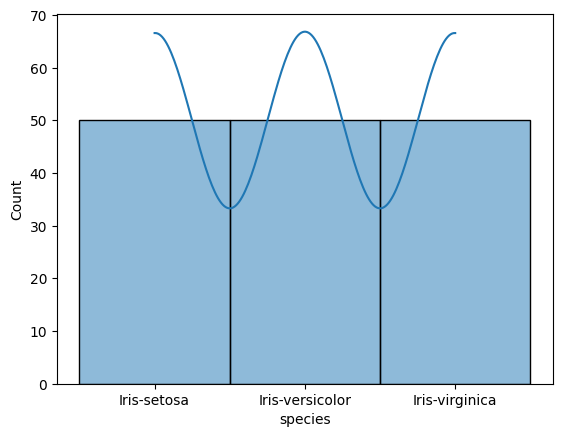

In [80]:
for i in df.columns:
    sns.histplot(df[i],kde=True)
    plt.show()

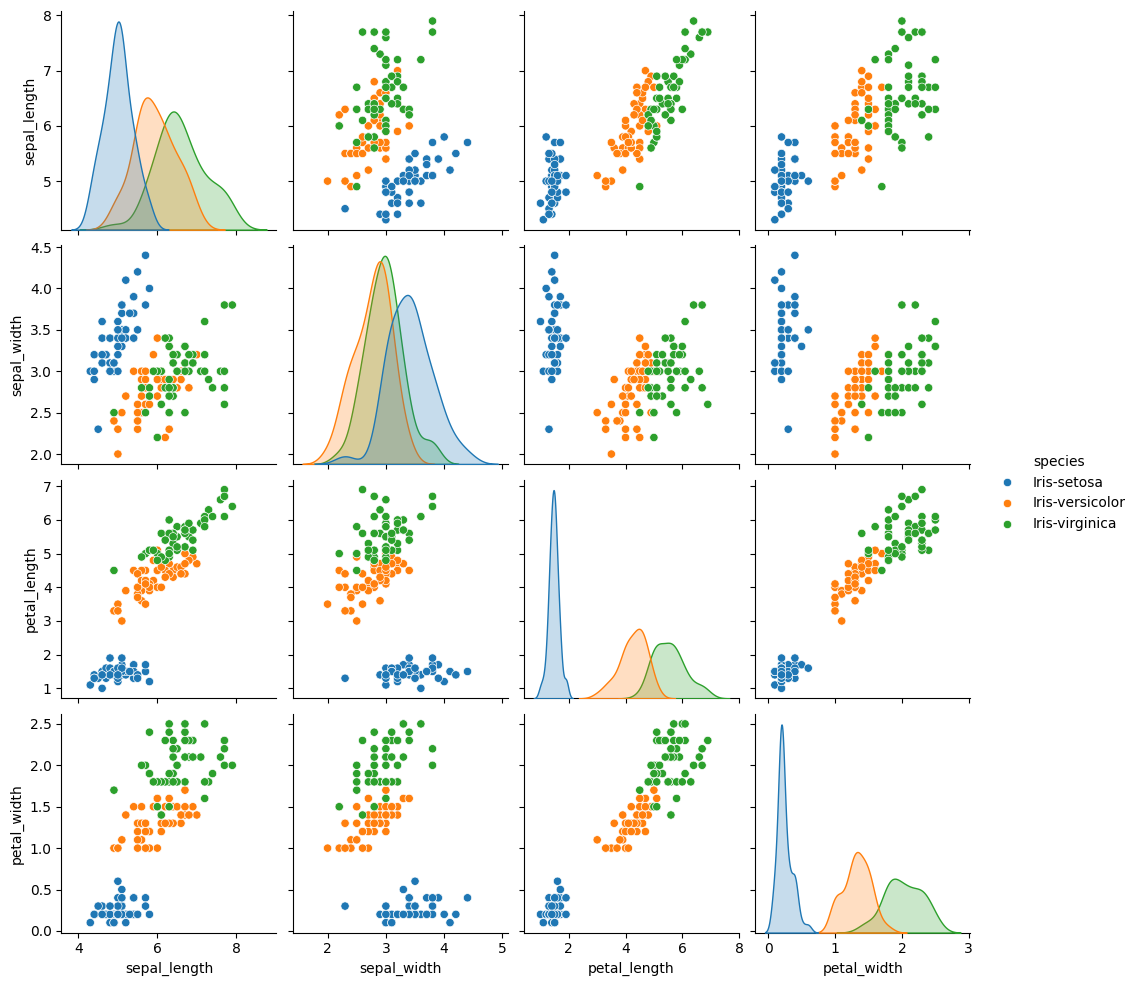

In [83]:
sns.pairplot(df,hue='species')